In [1]:
# environment: scenv
# snapatac2 version: 2.8.0

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import snapatac2 as snap
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
import pyranges as pr
import os
import warnings
import requests
from importlib import reload
from umap import UMAP
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cross_decomposition import CCA

from tqdm import tqdm
tqdm.pandas()

import sys
sys.path.append('/data1/normantm/multiome_collab')
from perturbseq import *
import multiome as mo

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [2]:
expt = mo.MultiomeExperiment.load('/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_multiomeTFs.pkl')

In [3]:
expt.gex.obs.total_counts.median(), expt.gex.obs.n_genes_by_counts.median(), expt.atac.obs.n_fragment.median(), expt.atac.obs.tsse.median()

(np.float32(5632.0),
 np.float64(2570.0),
 np.float64(20135.0),
 np.float64(16.551299800030762))

### 1b on-target activation

In [10]:
expt.experiment_dir = '/data1/normantm/multiome_collab/RPE1/cellranger_outs'
singlets = pd.concat([expt.singlets_assigned[sample] for sample in expt.sample_names], axis = 0)
adatas = []
for sample_name in tqdm(expt.sample_names):
    adata = sc.read_10x_h5(f"{expt.experiment_dir}/{sample_name}/outs/filtered_feature_bc_matrix.h5")
    adata.var_names_make_unique()
    adata.obs.index = adata.obs.index.map(lambda cb: cb.split("-")[0] + '-' + str(sample_name.split('Lane')[1].split('_')[0]))
    adata.obs = adata.obs.join(expt.singlets_assigned[sample_name][['guide_target', 'identity', 'LB_identity', 'joint_id', 'joint_id_ntc','UMI']], how = 'left')
    adata.obs = adata.obs.rename(columns = {'UMI': 'ID_UMI'})
    singlets = adata[adata.obs['identity'].notna(),:].copy()
    singlets.obs['gem_group'] = singlets.obs.index[0].split("-")[1]
    singlets.obs['guide_identity'] = singlets.obs.identity.map(lambda i: i.split("_")[0])
    adatas.append(singlets)

adata = ad.concat(adatas, join = 'outer', fill_value = 0)
sc.pp.normalize_total(adata, target_sum=1e6)
adata.var["mito"] = adata.var_names.str.startswith("MT-")
adata = adata[:,~adata.var_names.str.startswith("MT-")].copy()

  0%|          | 0/6 [00:00<?, ?it/s]/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
 17%|█▋        | 1/6 [00:05<00:27,  5.43s/it]/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
 33%|███▎      | 2/6 [00:10<00:21,  5.47s/it]/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/pytho

In [225]:
df = adata.to_df().join(adata.obs.joint_id_ntc).groupby('joint_id_ntc').mean()
df.index = df.index.map(lambda i: i.replace("NKX25", "NKX2-5").replace("NKX31", "NKX3-1"))
ntc_expr = df.loc['NTC'].map(lambda x: 0 if x < 0.001 else x).map(lambda x: np.log10(1e-6 + x))
ntc_expressed = ntc_expr.to_frame().query("NTC > -6")
expr_min, expr_max = ntc_expressed.min().item(), ntc_expressed.max().item()
ntc_expressed['ref_pctl'] = ntc_expressed.NTC.map(lambda x: 100 * (x - expr_min) / (expr_max - expr_min))
pctl_transformer = interp1d(ntc_expressed.NTC, ntc_expressed.ref_pctl, fill_value = 'extrapolate')

df_pctl = (
    df.copy()
      .map(lambda x: 0 if x < 0.001 else x)
      .map(lambda x: np.log10(1e-6 + x))
      .replace(-6, np.nan)
      .progress_apply(pctl_transformer)
      .fillna(0)
)

100%|██████████| 36588/36588 [00:04<00:00, 7665.60it/s]


In [226]:
target_genes = expt.all_singlets_assigned.query("guide_target != 'NTC'").guide_target.unique()
ntc_guide_targets = df_pctl.loc['NTC', target_genes].T.to_frame("NTC_expr")
ontarget_expr = pd.DataFrame(index = df_pctl.drop("NTC", axis = 0).index)
ontarget_expr.index = ontarget_expr.index.map(lambda i: i.replace("NKX25", "NKX2-5").replace("NKX31", "NKX3-1"))
ontarget_expr['NTC_pctl'] = ontarget_expr.index.map(lambda i: ntc_guide_targets.loc[i.split("_")[0], 'NTC_expr'].item())
ontarget_expr['target_pctl'] = ontarget_expr.index.map(lambda i: df_pctl.loc[i, i.split("_")[0]].item())
ontarget_expr['pctl_change'] = ontarget_expr.target_pctl - ontarget_expr.NTC_pctl
ontarget_expr = ontarget_expr.join(expt.all_singlets_assigned.joint_id_ntc.value_counts().to_frame("n_cells"), how = 'inner')

/tmp/ipykernel_737718/2652532818.py:20: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

/tmp/ipykernel_737718/2652532818.py:21: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

2026-03-12 13:57:09 - INFO - maxp pruned
2026-03-12 13:57:09 - INFO - cmap pruned
2026-03-12 13:57:09 - INFO - post pruned
2026-03-12 13:57:09 - INFO - FFTM dropped
2026-03-12 13:57:09 - INFO - GPOS pruned
2026-03-12 13:57:09 - INFO - GSUB pruned
2026-03-12 13:57:09 - INFO - glyf pruned
2026-03-12 13:57:09 - INFO - Added gid0 to subset
2026-03-12 13:57:09 - INFO - Added first four glyphs to subset
2026-03-12 13:57:09 - INFO - Closing glyph list over 'GSUB': 25 glyphs before
2026-03-12 13:57:09 - INFO - Glyph names: ['.notdef', '.null', 'E', 'a', 'c', 'e', 'eight', 'four', 'g', 'i', 'l', 'n', 'nonmarkingreturn', '

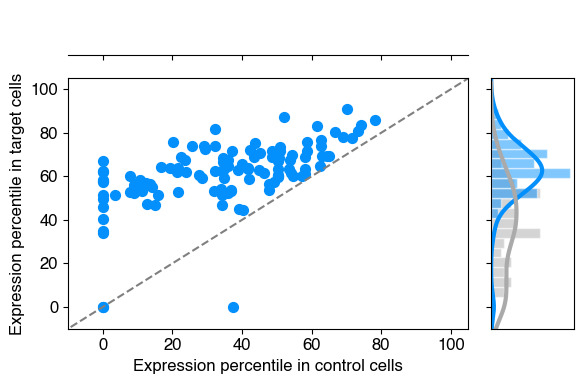

In [229]:
# from crispra paper: marginal histograms only include expressed targets

ontarget_expr = ontarget_expr.query("n_cells >= 20").copy()
g = sns.JointGrid(x="NTC_pctl", y="target_pctl", data=ontarget_expr,height=3.2,ratio=4)
g.figure.set_size_inches(6,4)

g.ax_joint.scatter(ontarget_expr['NTC_pctl'], ontarget_expr['target_pctl'], c='#0390fc', s=50, edgecolors=None)
g.ax_joint.plot([-20,120], [-20,120], linestyle='--', color='grey')

g.ax_joint.set_xlabel("Expression percentile in control cells")
g.ax_joint.set_ylabel("Expression percentile in target cells")

ax_marg = g.ax_marg_y
all_values = np.concatenate([ontarget_expr['target_pctl'], ontarget_expr['NTC_pctl']])
bin_edges = np.histogram_bin_edges(all_values, bins=20)

ax_marg.hist(ontarget_expr.query("NTC_pctl > 0")['NTC_pctl'], bins=bin_edges, orientation='horizontal', color='#aaaaaa', alpha=0.5, edgecolor='white', density=True)
ax_marg.hist(ontarget_expr.query("NTC_pctl > 0")['target_pctl'], bins=bin_edges, orientation='horizontal', color='#0390fc', alpha=0.5, edgecolor='white', density=True)

sns.kdeplot(ontarget_expr['target_pctl'], ax=ax_marg, vertical=True, color='#0390fc', linewidth=3)
sns.kdeplot(ontarget_expr['NTC_pctl'], ax=ax_marg, vertical=True, color='#aaaaaa', linewidth=3)

for spine in g.ax_joint.spines.values():
    spine.set_visible(True)

for spine in g.ax_marg_y.spines.values():
    spine.set_visible(True)

g.ax_joint.set_xlim(-10, 105)  # x-axis limits for scatter only
g.ax_joint.set_ylim(-10,105)  # y-axis limits for scatter only

plt.tight_layout()
plt.savefig("1b_ontarget_expr.pdf")
plt.show()

### 1c ATAC/GEX coembedding

In [22]:
tgts = expt.gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")
gex = expt.gex[expt.gex.obs.guide_target.isin(tgts.index),:].copy()
sc.pp.pca(gex, n_comps = 29, random_state = 42)
atac = expt.atac[expt.atac.obs.guide_target.isin(tgts.index),:].copy()
snap.tl.spectral(atac, random_state = 42)

In [111]:
df_pca = pd.DataFrame(gex.obsm['X_pca'], index = gex.obs.index).join(gex.obs.joint_id_ntc).groupby('joint_id_ntc').mean()
df_pca.columns = [f'PC{i+1}' for i in range(df_pca.shape[1])]
df_spectral = pd.DataFrame(atac.obsm['X_spectral'][:,1:], index = atac.obs.index).join(atac.obs.joint_id_ntc).groupby('joint_id_ntc').mean()
df_spectral.columns = [f'SC{i+1}' for i in range(df_spectral.shape[1])]

/tmp/ipykernel_1053257/2848685150.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [112]:
X_gex = normalize(StandardScaler().fit_transform(df_pca))
X_atac = normalize(StandardScaler().fit_transform(df_spectral))
cca = CCA(n_components=29)
X_gex_cca, X_atac_cca = cca.fit_transform(X_gex, X_atac)
df_coembed = np.hstack([X_gex_cca, X_atac_cca])

/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
/tmp/ipykernel_1053257/2839582226.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_1053257/2839582226.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


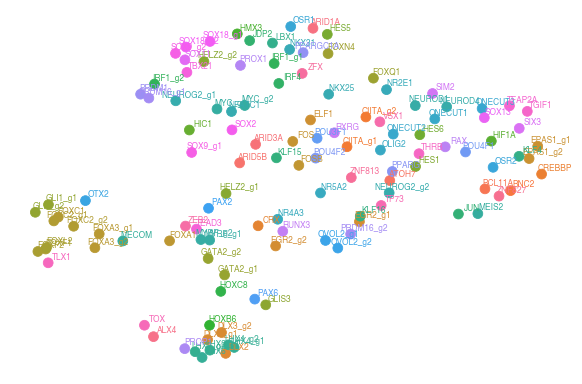

In [113]:
umap = UMAP(metric = 'correlation', n_neighbors=10, min_dist = 0.01, spread = 2, random_state = 42)
umap_rep = umap.fit_transform(df_coembed)

df = pd.DataFrame(umap_rep, index = df_pca.index).reset_index().query("joint_id_ntc != 'NTC'")
df['tgt'] = df.joint_id_ntc.str.split("_").str[0]
df['tgt'] = pd.Categorical(df.tgt, ordered=True, categories = pd.Series(df.tgt.unique()).sort_values())
palette = sns.color_palette("husl", len(df.tgt.unique()))
color_mapping = dict(zip(df['tgt'].cat.categories, palette))

plt.figure(figsize = (6,4))
sns.scatterplot(data = df, x = 0, y = 1, hue = 'tgt', edgecolor = None, legend = None, s = 50)
df['n_guides'] = df.groupby('tgt').tgt.transform('count')
df['guide_number'] = df.groupby('tgt').tgt.transform('cumcount') + 1
df['corrected_name'] = df.apply(lambda df: df.tgt if df.n_guides == 1 else f"{df.tgt}_g{df.guide_number}", axis=1)
for idx, row in df.iterrows():
    plt.text(row[0] + 0.25,row[1] + 0.2, row.corrected_name, fontsize=6, color=color_mapping[row.tgt], ha='center', va='center')
plt.axis('off')
plt.tight_layout()
# plt.savefig(f"1c_joint_embedding.pdf", dpi = 300)
plt.show()

In [3]:
tgts = expt.gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")
palette = sns.color_palette("husl", len(tgts)).as_hex()
color_mapping = dict(zip(tgts.sort_index().index.tolist(), palette))
color_mapping

{'ALX4': '#f77189',
 'ARID1A': '#f77181',
 'ARID3A': '#f77278',
 'ARID5B': '#f7736e',
 'ATOH7': '#f77462',
 'BCL11A': '#f77553',
 'BNC2': '#f87640',
 'CIITA': '#f37a32',
 'CREBBP': '#ec7f32',
 'CRX': '#e58432',
 'DLX2': '#df8732',
 'DLX3': '#d98a32',
 'EGR2': '#d48d32',
 'ELF1': '#cf8f32',
 'EPAS1': '#ca9232',
 'FOS': '#c69432',
 'FOSB': '#c29532',
 'FOXA1': '#bd9732',
 'FOXA3': '#b99932',
 'FOXC1': '#b59a32',
 'FOXC2': '#b19b32',
 'FOXF1': '#ae9d31',
 'FOXF2': '#a99e31',
 'FOXL2': '#a5a031',
 'FOXN4': '#a1a131',
 'FOXQ1': '#9da231',
 'GATA2': '#98a331',
 'GLI1': '#93a531',
 'GLIS3': '#8ea631',
 'HELZ2': '#88a731',
 'HES1': '#82a931',
 'HES5': '#7baa31',
 'HES6': '#73ac31',
 'HIC1': '#6aad31',
 'HIF1A': '#5eaf31',
 'HMX3': '#50b131',
 'HOXB6': '#3ab331',
 'HOXC8': '#31b344',
 'IRF1': '#32b255',
 'IRF4': '#32b262',
 'JDP2': '#33b16c',
 'JUN': '#33b174',
 'KLF4': '#33b07a',
 'KLF15': '#34b080',
 'KLF16': '#34af85',
 'LBX1': '#34af8a',
 'LHX2': '#34af8e',
 'LHX4': '#35ae92',
 'LHX6': '#35

In [ ]:
chromvar = sc.read('/data1/normantm/multiome_collab/RPE1/RPE1_chromvar_znorm.h5ad')
chromvar.obs = chromvar.obs.join(expt.atac.obs[['joint_id_ntc']], how = 'left')
meanpop = sc.get.aggregate(chromvar, by = 'joint_id_ntc', func = 'mean')
df_chromvar = pd.DataFrame(meanpop.layers['mean'], index = meanpop.obs_names, columns = meanpop.var_names)
df_chromvar.columns = ['.'.join(c.split('.')[:-1]) for c in df_chromvar.columns]
cluster_meta = pd.read_csv('/data1/normantm/tmn/JASPAR_vertebrates_CORE_flat_metadata.tsv', sep='\t')

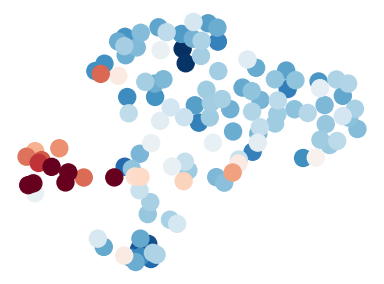

In [141]:
motif_df = df_chromvar.filter(items = cluster_meta.query("cluster_name == 'FOX'").matrix_id.tolist()).mean(axis = 1).sort_values().map(lambda x: np.clip(x, -1, 1)).to_frame('motif')
plt.figure(figsize = (4,3))
sns.scatterplot(data = df.set_index('joint_id_ntc').join(motif_df).sort_values('motif'), x = 0, y = 1, hue = 'motif', edgecolor = None, legend = None, s = 150, palette = 'RdBu_r')
plt.axis('off')
plt.tight_layout()
plt.savefig(f"1c_fox.pdf", dpi = 300)
plt.show()

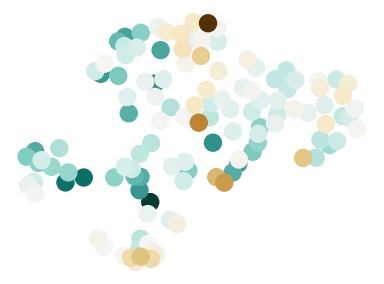

In [142]:
motif_df = df_chromvar.filter(items = cluster_meta.query("cluster_name.str.contains('JUN')").matrix_id.tolist()).mean(axis = 1).sort_values().map(lambda x: np.clip(x, -1, 1)).to_frame('motif')
plt.figure(figsize = (4,3))
sns.scatterplot(data = df.set_index('joint_id_ntc').join(motif_df).sort_values('motif'), x = 0, y = 1, hue = 'motif', edgecolor = None, legend = None, s = 150, palette = 'BrBG_r')
plt.axis('off')
plt.tight_layout()
plt.savefig(f"1c_ap1.pdf", dpi = 300)
plt.show()

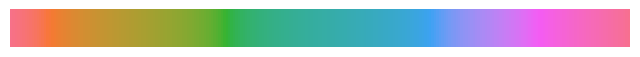

In [34]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
palette = sns.color_palette("husl", 119)
cmap = mcolors.LinearSegmentedColormap.from_list("husl", palette, N=256)
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)
norm = plt.Normalize(vmin=0, vmax=256)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax, orientation="horizontal")
plt.axis('off')
plt.savefig("colorbar_legend.pdf")
plt.show()

### 1d GEX/ATAC energy distance

In [ ]:
# estimator = 'U' and exponent = 2 are directly from the scPerturb supplementary note about deriving unbiased estimates of E-distance
# normalizing rows to 1 is a better way of getting distances on the same scale vs z-scoring, which still leaves GEX PCA with much higher variance so hard to tell which guides affect ATAC more
# fit 29 PCs to match the dimension of the spectral embedding

gex = expt.gex.copy()
sc.pp.pca(gex, n_comps = 29, random_state = 42)

In [ ]:
from sklearn.preprocessing import normalize, StandardScaler
np.bool = bool # this fixes a dcor bug for estimation_stat = 'U'
from dcor import energy_distance
from dcor.homogeneity import energy_test
from scipy.stats import false_discovery_control
import warnings

# see https://github.com/sanderlab/scPerturb/issues/30 - the scperturb authors don't explain why the squared euclidean distance is used, but that is how they do it in the paper even though within-group variance info is discarded

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    
    df_spectral = pd.DataFrame(normalize(expt.atac.obsm['X_spectral'][:,1:]), index = expt.atac.obs_names).join(expt.atac.obs.guide_target)
    ntc_spectral = df_spectral.query("guide_target == 'NTC'").drop(columns='guide_target').sample(n=200, random_state=42).to_numpy()

    df_pca = pd.DataFrame(normalize(gex.obsm['X_pca']), index = gex.obs_names).join(gex.obs.guide_target)
    ntc_pca = df_pca.query("guide_target == 'NTC'").drop(columns='guide_target').sample(n=200, random_state=42).to_numpy()
    print(df_pca.shape)
    print(df_spectral.shape)
    assert df_pca.shape == df_spectral.shape

    guides = [g for g in expt.atac.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20").index if g != 'NTC']
    df_energy = pd.DataFrame(index = guides, columns = ['distance_spectral', 'distance_pca', 'p_spectral', 'p_pca'])
    for g in tqdm(guides):
        tgt_spectral = df_spectral.query("guide_target == @g").drop(columns='guide_target').to_numpy()
        tgt_pca = df_pca.query("guide_target == @g").drop(columns='guide_target').to_numpy()
        df_energy.loc[g, 'distance_spectral'] = energy_distance(ntc_spectral, tgt_spectral, exponent=2, estimation_stat = 'U')
        df_energy.loc[g, 'distance_pca'] = energy_distance(ntc_pca, tgt_pca, exponent=2, estimation_stat = 'U')
        df_energy.loc[g, 'p_spectral'] = energy_test(ntc_spectral, tgt_spectral, exponent=2, estimation_stat = 'U', n_jobs = 8, num_resamples=1000, random_state=42).pvalue
        df_energy.loc[g, 'p_pca'] = energy_test(ntc_pca, tgt_pca, exponent=2, estimation_stat = 'U', n_jobs = 8, num_resamples=1000, random_state=42).pvalue

df_energy['q_spectral'] = false_discovery_control(df_energy['p_spectral'].astype(np.float64))
df_energy['q_pca'] = false_discovery_control(df_energy['p_pca'].astype(np.float64))
df_energy = df_energy.join(expt.gex.obs.guide_target.value_counts().to_frame('ncells').ncells)

(25129, 30)
(25129, 30)


100%|██████████| 104/104 [03:08<00:00,  1.81s/it] 


In [16]:
df_energy.to_csv('df_energy.csv')

2026-07-24 10:40:53 - INFO - maxp pruned
2026-07-24 10:40:53 - INFO - cmap pruned
2026-07-24 10:40:53 - INFO - post pruned
2026-07-24 10:40:53 - INFO - FFTM dropped
2026-07-24 10:40:53 - INFO - GPOS pruned
2026-07-24 10:40:53 - INFO - GSUB pruned
2026-07-24 10:40:53 - INFO - glyf pruned
2026-07-24 10:40:53 - INFO - Added gid0 to subset
2026-07-24 10:40:53 - INFO - Added first four glyphs to subset
2026-07-24 10:40:53 - INFO - Closing glyph list over 'GSUB': 52 glyphs before
2026-07-24 10:40:53 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z', 'a', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'hyphen', 'i', 'n', 'nine', 'nonmarkingreturn', 'one', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'uni0008', 'y', 'zero']
2026-07-24 10:40:53 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 38, 39, 40, 41, 42, 43, 44, 45, 46, 4

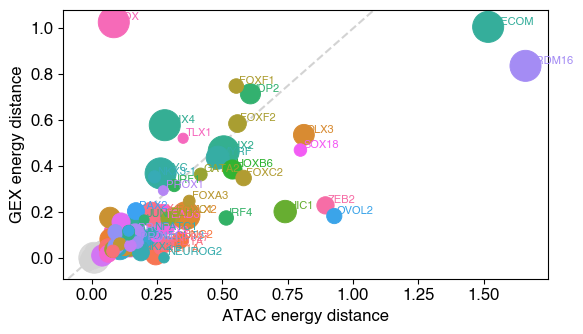

In [15]:
# df_energy = pd.read_csv('df_energy.csv', index_col = 0)

labels = [i.replace("NKX25", 'NKX2-5').replace("NKX31", 'NKX3-1') for i in np.sort(df_energy.index)]
pal = sns.color_palette("husl", len(labels))
color_mapping = dict(zip(labels, pal))
df_energy['ncells_plot'] = np.clip(df_energy.ncells, 25, 500)
df_energy['guide_target'] = df_energy.index.map(lambda i: i.replace("NKX25", 'NKX2-5').replace("NKX31", 'NKX3-1'))
# plt.figure(figsize = (9,6))
plt.figure(figsize = (6,3.5))
sns.scatterplot(df_energy.query("q_spectral >= 0.002 and q_pca >= 0.002"), x = 'distance_spectral', y = 'distance_pca', color = 'lightgrey', alpha = 0.8, edgecolor = None, legend = None, size = 'ncells_plot', sizes = (50,500))
sns.scatterplot(df_energy.query("q_spectral < 0.002 or q_pca < 0.002"), x = 'distance_spectral', y = 'distance_pca', hue = 'guide_target', palette = color_mapping, edgecolor = None, legend = None, size = 'ncells_plot', sizes = (50,500))
plt.axline([0,0], slope = 1, linestyle = 'dashed', color = 'lightgrey', zorder = -1)
for idx, row in df_energy.iterrows():
    if row.distance_pca > 0.2 or row.distance_spectral > 0.16:
        plt.text(row.distance_spectral + 0.01, row.distance_pca + 0.01, row.guide_target, color = color_mapping[row.guide_target], fontsize=8)
plt.xlabel("ATAC energy distance")
plt.ylabel("GEX energy distance")
plt.tight_layout()
# plt.savefig('1d_energy.pdf')
# plt.savefig('1d_energy_v2.pdf')
plt.savefig('1d_energy_v3.pdf')
plt.show()

In [ ]:
labels = [i.replace("NKX25", 'NKX2-5').replace("NKX31", 'NKX3-1') for i in np.sort(df_energy.index)]
pal = sns.color_palette("husl", len(labels))
color_mapping = dict(zip(labels, pal))
df_energy['ncells_plot'] = np.clip(df_energy.ncells, 25, 500)
df_energy['guide_target'] = df_energy.index.map(lambda i: i.replace("NKX25", 'NKX2-5').replace("NKX31", 'NKX3-1'))
plt.figure(figsize = (7,6))
sns.scatterplot(df_energy.query("q_spectral >= 0.002 and q_pca >= 0.002"), x = 'distance_spectral', y = 'distance_pca', color = 'lightgrey', alpha = 0.8, edgecolor = None, legend = None, size = 'ncells_plot', sizes = (50,500))
sns.scatterplot(df_energy.query("q_spectral < 0.002 or q_pca < 0.002"), x = 'distance_spectral', y = 'distance_pca', hue = 'guide_target', palette = color_mapping, edgecolor = None, legend = None, size = 'ncells_plot', sizes = (50,500))
plt.axline([0,0], slope = 1, linestyle = 'dashed', color = 'lightgrey', zorder = -1)
for idx, row in df_energy.iterrows():
    if row.distance_pca > 0.2 or row.distance_spectral > 0.16:
        plt.text(row.distance_spectral + 0.01, row.distance_pca + 0.01, row.guide_target, color = color_mapping[row.guide_target], fontsize=10)
plt.xlabel("ATAC energy distance")
plt.ylabel("GEX energy distance")
plt.tight_layout()
plt.savefig('1d_energy_slide.pdf')
plt.show()

### 1e chromvar dotplot

In [3]:
ncells = expt.all_singlets_assigned.guide_target.value_counts().to_frame("n_cells")
ncells = ncells.query("n_cells >= 20").index

In [17]:
df_ont = pd.read_csv("/data1/normantm/eli/scprinter/RPE1_jaspar26_chromvar_motifs_differential.csv").query("q < 0.1").copy() # jaspar26 by guide
df_ont['guide_target'] = df_ont.guide_target.map(lambda i: i.replace('NKX25', 'NKX2-5').replace('NKX31', 'NKX3-1'))
df_ont['gene'] = df_ont.gene.str.split(".").str[-1]
df_ont.sort_values("q", inplace = True)
df_ont['gene'] = df_ont.gene.str.upper()
df_ont = df_ont.drop_duplicates(["gene", "guide_target"], keep = 'first')
df_ont = df_ont.query("guide_target.isin(@ncells)").copy()
df_ont = df_ont.query("gene.isin(@df_ont.guide_target)").copy()
df_ont['gene'] = pd.Categorical(df_ont.gene, ordered=True, categories = pd.Series(df_ont.gene.unique()).sort_values())
df_ont.guide_target = pd.Categorical(df_ont.guide_target, ordered=True, categories = pd.Series(df_ont.guide_target.unique()).sort_values())
df_ont['logq'] = df_ont.q.map(lambda x: np.clip(-np.log10(x),1,10))
df_ont['z'] = np.clip(df_ont.z, -1, 1)

2026-08-31 16:56:50 - INFO - maxp pruned
2026-08-31 16:56:50 - INFO - cmap pruned
2026-08-31 16:56:50 - INFO - post pruned
2026-08-31 16:56:50 - INFO - FFTM dropped
2026-08-31 16:56:50 - INFO - GPOS pruned
2026-08-31 16:56:50 - INFO - GSUB pruned
2026-08-31 16:56:50 - INFO - glyf pruned
2026-08-31 16:56:50 - INFO - Added gid0 to subset
2026-08-31 16:56:50 - INFO - Added first four glyphs to subset
2026-08-31 16:56:50 - INFO - Closing glyph list over 'GSUB': 56 glyphs before
2026-08-31 16:56:50 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'eight', 'f', 'five', 'four', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'uni0008']
2026-08-31 16:56:50 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 18, 22, 23, 24, 25, 26, 27, 28, 29, 30, 38, 39, 40, 41, 42, 43, 44, 45, 4

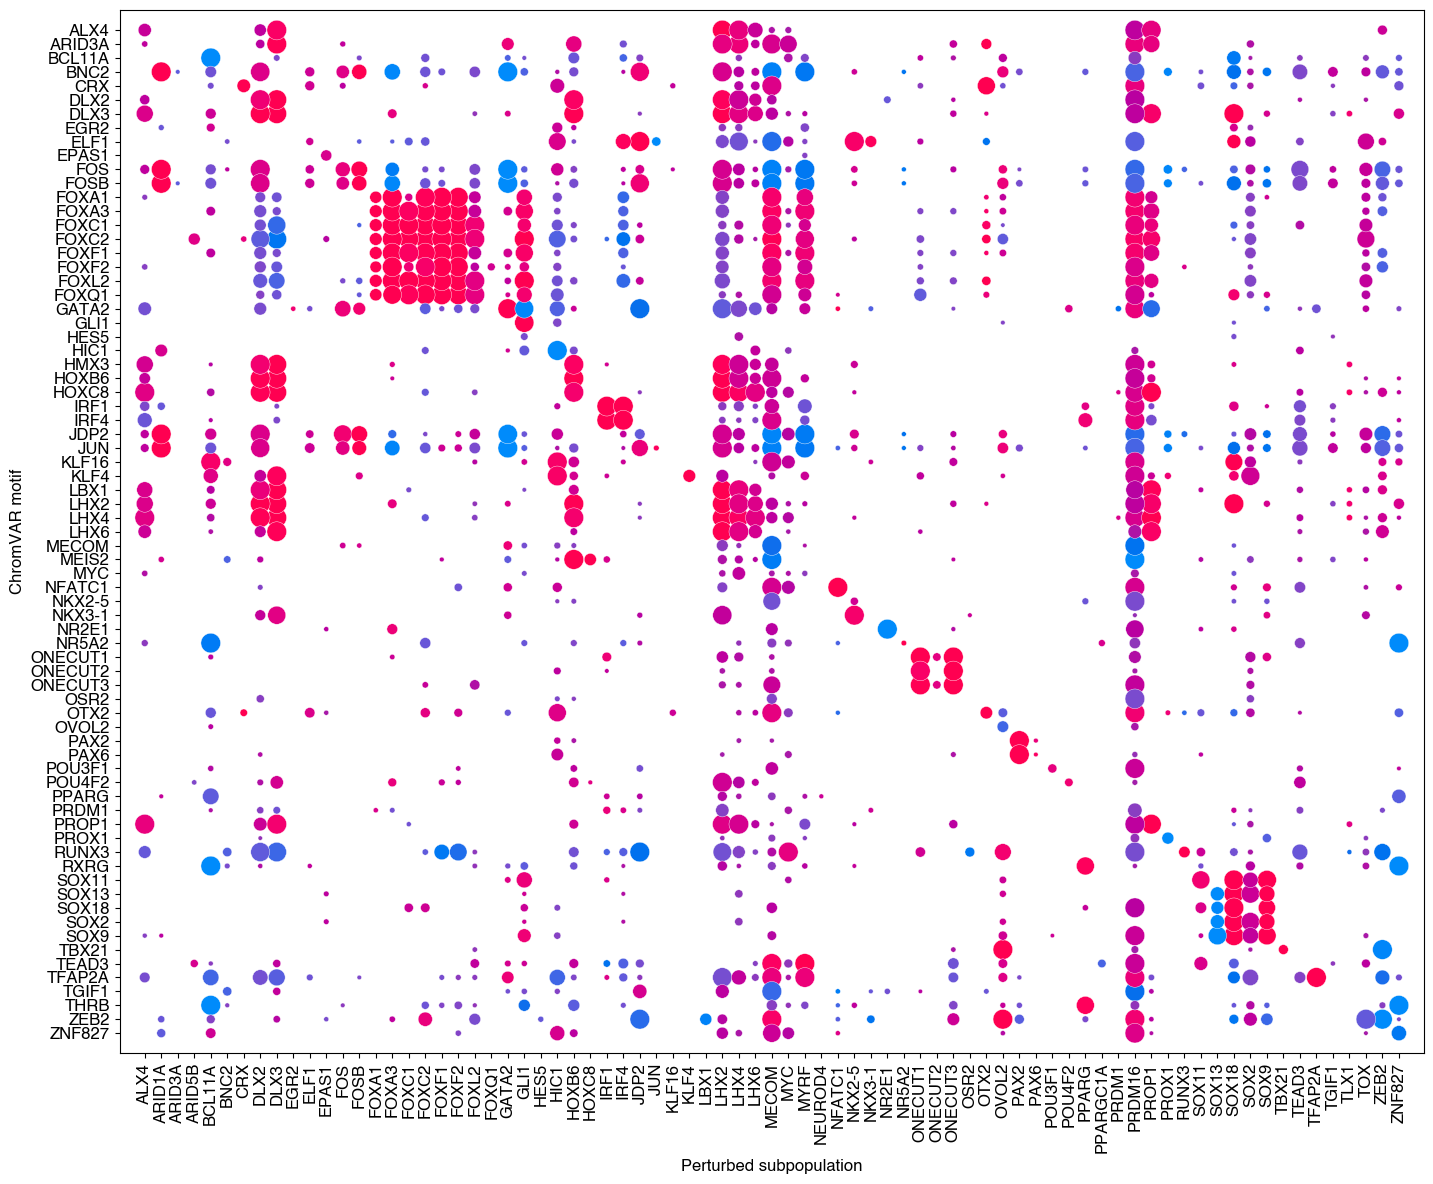

In [ ]:
from shap.plots.colors import red_blue
# plt.figure(figsize = (16,12))
plt.figure(figsize = (14.5,12))
sns.scatterplot(data = df_ont, x = 'guide_target', y = 'gene', hue = 'z', size = 'logq', sizes = (10, 200), palette = red_blue, legend = None)
plt.xticks(rotation = 90)
plt.margins(x=0.02, y=0.02)
plt.xlabel('Perturbed subpopulation')
plt.ylabel('ChromVAR motif')
plt.tight_layout()
plt.savefig("plots/1e_chromvar_dotplot_v3.pdf")
plt.show()

### 1f pioneer scatter

In [11]:
# adata from 1b

df = adata.to_df().join(adata.obs.guide_target).groupby('guide_target').mean()
df.index = df.index.map(lambda i: i.replace("NKX25", "NKX2-5").replace("NKX31", "NKX3-1"))
ntc_expr = df.loc['NTC'].map(lambda x: 0 if x < 0.001 else x).map(lambda x: np.log10(1e-6 + x))

ntc_expressed = ntc_expr.to_frame().query("NTC > -6")
expr_min, expr_max = ntc_expressed.min().item(), ntc_expressed.max().item()

ntc_expressed['ref_pctl'] = ntc_expressed.NTC.map(lambda x: 100 *(x - expr_min) / (expr_max - expr_min))
pctl_transformer = interp1d(ntc_expressed.NTC, ntc_expressed.ref_pctl, fill_value = 'extrapolate')

df_pctl = (
    df.copy()
      .map(lambda x: 0 if x < 0.001 else x)
      .map(lambda x: np.log10(1e-6 + x))
      .replace(-6, np.nan)
      .progress_apply(pctl_transformer)
      .fillna(0)
)

100%|██████████| 36588/36588 [00:02<00:00, 13900.15it/s]


In [12]:
df_newly_expressed = df_pctl.T.query("not index.isin(@expt.gex.var_names)").T.apply(lambda row: row[row > 0], axis=1).stack().reset_index()
df_newly_expressed.columns = ['guide_target', 'newly_expressed_gene', 'pctl_change']
df_concordance = expt.daps.query("n_cells >= 20").copy()
df_concordance.rename(columns = {'gene_name': 'gene'}, inplace = True)

In [13]:
from joblib import Parallel, delayed

def find_expr_match(row, degs, newly_expressed, new_expr_threshold=10):
    
    if row.n_cells >= 20:
        if row.gene in expt.gex.var_names:
            deg = degs[(degs.gene == row.gene) & (np.sign(degs.z) == np.sign(row.l2fc))]
            return len(deg) == 1, False, deg.z.item() if len(deg) > 0 else np.nan, np.nan
        else:
            deg = newly_expressed.query("pctl_change >= @new_expr_threshold and newly_expressed_gene == @row.gene")
            concordant = row.l2fc > 0 and len(deg) == 1
            return concordant, True if concordant else pd.NA, np.nan, deg.pctl_change.item() if len(deg) > 0 else np.nan
    else:
        return pd.NA, pd.NA, pd.NA, pd.NA

def get_concordant_expr(guide):
    
    degs = expt.degs.query("guide_target == @guide")
    newly_expressed = df_newly_expressed.query("guide_target == @guide")
    df = df_concordance.query("guide_target == @guide").copy()
    df[['concordant_expr', 'newly_expressed', 'deg_z', 'pctl_change']] = df.apply(lambda row: find_expr_match(row, degs, newly_expressed), axis=1, result_type="expand")
    
    return df

dfs = Parallel(n_jobs=8, verbose = 100)(delayed(get_concordant_expr)(guide) for guide in df_concordance.guide_target.unique())
df_final = pd.concat(dfs, axis = 0)

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   26.3s
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   28.6s
[Parallel(n_jobs=8)]: Done   3 tasks      | elapsed:   37.6s
[Parallel(n_jobs=8)]: Done   4 tasks      | elapsed:   38.1s
[Parallel(n_jobs=8)]: Done   5 tasks      | elapsed:   41.7s
[Parallel(n_jobs=8)]: Done   6 tasks      | elapsed:   48.2s
[Parallel(n_jobs=8)]: Done   7 tasks      | elapsed:   48.3s
[Parallel(n_jobs=8)]: Done   8 tasks      | elapsed:   52.1s
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:   52.2s
[Parallel(n_jobs=8)]: Done  10 tasks      | elapsed:   56.0s
[Parallel(n_jobs=8)]: Done  11 tasks      | elapsed:   57.1s
[Parallel(n_jobs=8)]: Done  12 tasks      | elapsed:  1.1min
[Parallel(n_jobs=8)]: Done  13 tasks      | elapsed:  1.1min
[Parallel(n_jobs=8)]: Done  14 tasks      | elapsed:  1.1min
[Parallel(n_jobs=8)]: Done  15 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Do

In [14]:
df_final['concordant_expr'] = df_final.progress_apply(lambda df: df.concordant_expr if df.n_cells >= 20 else pd.NA, axis = 1)
df_final['newly_expressed'] = df_final.progress_apply(lambda df: pd.NA if df.n_cells < 20 else not np.isnan(df.pctl_change), axis = 1)

import scipy.sparse as sp

X = adata.X.tocsr()

groups = adata.obs["guide_target"].astype("category")
group_codes = groups.cat.codes.to_numpy()
unique_groups = groups.cat.categories

genes = df_newly_expressed.newly_expressed_gene.unique()
gene_idx = adata.var_names.get_indexer(genes)

rows = []
for gid, g in enumerate(unique_groups):

    ridx = np.where(group_codes == gid)[0]
    if ridx.size == 0:
        continue

    Xg = X[ridx][:, gene_idx]

    n_expressing = np.asarray((Xg > 0).sum(axis=0)).ravel()

    rows.append(pd.DataFrame({
        "guide_target": g,
        "gene": genes,
        "count_profile": n_expressing
    }))

df_counts = pd.concat(rows, ignore_index=True)
df_final = df_final.merge(df_counts,on=["guide_target", "gene"],how="left")

100%|██████████| 371650/371650 [00:04<00:00, 83761.18it/s]


In [16]:
ncells = expt.all_singlets_assigned.guide_target.value_counts().to_frame("n_cells")
ncells = ncells.query("n_cells >= 20").index

df_ont = pd.read_csv("/data1/normantm/multiome_collab/RPE1/intermediate_files/RPE1_chromvar_motifs_differential.csv")
df_ont['guide_target'] = df_ont.guide_target.map(lambda i: i.replace('NKX25', 'NKX2-5').replace('NKX31', 'NKX3-1'))
df_ont['gene'] = df_ont.gene.str.split(".").str[-1]
df_ont.sort_values("q", inplace = True)
df_ont['gene'] = df_ont.gene.str.upper()
df_ont = df_ont.drop_duplicates(["gene", "guide_target"], keep = 'first')
df_ont = df_ont.query("guide_target.isin(@ncells)").copy()
df_ont = df_ont.query("gene.isin(@df_ont.guide_target)").copy()
df_ont['ontarget'] = df_ont.apply(lambda df: df.gene == df.guide_target, axis = 1)
df_pioneer = df_ont.query('ontarget').drop('ontarget', axis = 1)

In [17]:
df_final['count_profile_pct'] = df_final.apply(lambda df: df.count_profile / df.n_cells, axis = 1)
df_enrichment = df_final.query("count_profile_pct >= 0.1")[['guide_target', 'gene', 'n_cells']].drop_duplicates().guide_target.value_counts().to_frame()

In [18]:
df_pioneer_plot = df_pioneer.set_index('guide_target').join(df_enrichment).rename({"count": "newly_expressed_genes"}, axis = 1).fillna(0).join(expt.gex.obs.guide_target.value_counts().to_frame('ncells')).reset_index()
df_pioneer_plot['guide_target'] = pd.Categorical(df_pioneer_plot.guide_target, categories = pd.Series(df_pioneer_plot.guide_target.unique()).sort_values(), ordered = True)

In [19]:
labels = pd.Series(expt.gex.obs.guide_target.value_counts().to_frame("ncells").query("ncells >= 20 and index != 'NTC'").index).sort_values()
labels = [i.replace("NKX25", 'NKX2-5').replace("NKX31", 'NKX3-1') for i in labels]
pal = sns.color_palette("husl", len(labels))
color_mapping = dict(zip(labels, pal))

/tmp/ipykernel_1328594/3479387493.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
2026-06-15 17:50:07 - INFO - maxp pruned
2026-06-15 17:50:07 - INFO - cmap pruned
2026-06-15 17:50:07 - INFO - post pruned
2026-06-15 17:50:07 - INFO - FFTM dropped
2026-06-15 17:50:07 - INFO - GPOS pruned
2026-06-15 17:50:07 - INFO - GSUB pruned
2026-06-15 17:50:07 - INFO - glyf pruned
2026-06-15 17:50:07 - INFO - Added gid0 to subset
2026-06-15 17:50:07 - INFO - Added first four glyphs to subset
2026-06-15 17:50:07 - INFO - Closing glyph list over 'GSUB': 59 glyphs before
2026-06-15 17:50:07 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Z', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'uni0008', 'w', 'x', 'y'

['ARID1A' 'MYRF' 'NTC']


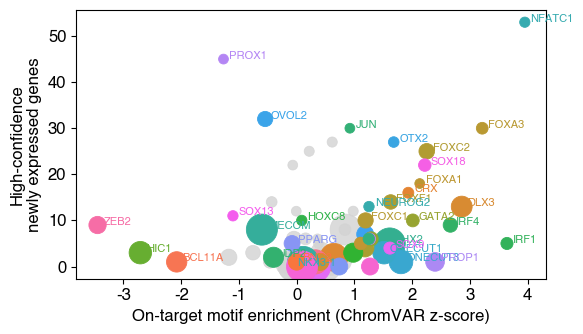

In [24]:
dg50 = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex.h5ad').obs.query("not guide_target.str.contains('_')").guide_target.unique()
dg50 = [i.replace("NKX25", "NKX2-5").replace("NKX31", "NKX3-1") for i in dg50]
print(np.setdiff1d(dg50, df_pioneer_plot.query("guide_target.isin(@dg50)").guide_target.unique()))
df_pioneer_plot['ncells_plot'] = np.clip(df_pioneer_plot.ncells, 25, 500)
# plt.figure(figsize = (7.5,6))
plt.figure(figsize = (6,3.5))
sns.scatterplot(data = df_pioneer_plot.query("not guide_target.isin(@dg50)"), x = 'z', y = 'newly_expressed_genes', edgecolor = None, color = 'lightgrey', alpha = 0.8, palette = color_mapping, legend = None, size = 'ncells_plot', sizes = (50,500))
sns.scatterplot(data = df_pioneer_plot.query("guide_target.isin(@dg50)"), x = 'z', y = 'newly_expressed_genes', edgecolor = None, hue = 'guide_target', alpha = 1, palette = color_mapping, legend = None, size = 'ncells_plot', sizes = (50,500))

for i, row in df_pioneer_plot.iterrows():
    if row.guide_target in dg50 and (row.z < 0 or row.z > 1.5 or row.newly_expressed_genes > 7):
        plt.text(row.z + 0.1, row.newly_expressed_genes + 0.1, row.guide_target, fontsize=8, color=color_mapping[row.guide_target])

plt.xlabel("On-target motif enrichment (ChromVAR z-score)")
plt.ylabel("High-confidence\nnewly expressed genes")
plt.tight_layout()
# plt.savefig("1f_pioneer_tgt.pdf")
plt.savefig('1f_pioneer_tgt_v2.pdf')
plt.show()

### 1g priming circos plot

In [2]:
df_doubles = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/3D_emb_geometry.csv")
gex = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex.h5ad')

sctfs_exact = pd.read_csv("/data1/normantm/eli/T7/202412_multiome_TFs/analysis/intermediate_files/sc_motif_scores_differential.csv", index_col = 0)
chromvar_exact = pd.read_csv("/data1/normantm/eli/scprinter/RPE1_jaspar26_chromvar_motifs_differential.csv").query("q < 0.1")
chromvar_exact['gene'] = chromvar_exact['gene'].str.split(".").str[-1]
df_scores = pd.concat([sctfs_exact, chromvar_exact], axis=0)
mapper = {'Alx4': 'ALX4', 'Crx': 'CRX', 'Dlx2': 'DLX2', 'Dlx3': 'DLX3', 'Irf1': 'IRF1', 'Hic1': 'HIC1', 'Nfatc1': 'NFATC1', 'Foxf1': 'FOXF1', 'Jun': 'JUN', 'Nkx3-1': 'NKX31', 'NKX2-5': 'NKX25', 'Gli1': 'GLI1', 'Fosb': 'FOSB', 'Mecom': 'MECOM'}
df_scores['corrected_motif'] = df_scores['gene'].map(lambda g: mapper.get(g, g))
df_scores = df_scores.sort_values('q').drop_duplicates(['corrected_motif', 'guide_target'], keep='first')

def get_priming_score(df):

    first, second = df.guide_target.split('_')
    primed_ab, primed_ba = df_scores.query("corrected_motif == @first and guide_target == @second"), df_scores.query("corrected_motif == @second and guide_target == @first")

    z_ab = primed_ab.z.item() if not primed_ab.empty else None
    z_ba = primed_ba.z.item() if not primed_ba.empty else None

    return z_ab, z_ba

from tqdm import tqdm
tqdm.pandas()
df_doubles[['primed_ab', 'primed_ba']] = df_doubles.progress_apply(get_priming_score, axis = 1, result_type = 'expand')
df_doubles['is_primed'] = df_doubles.apply(lambda df: df.primed_ab > 0 or df.primed_ba > 0, axis = 1)
is_homolog = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/is_homolog.csv", usecols = [0,1], index_col = 0).query("is_homolog == True").index.tolist()

df_doubles['is_primed_no_homolog'] = df_doubles.apply(lambda df: df.is_primed and df.guide_target not in is_homolog, axis = 1)

degs = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_degs.csv")
tgts = degs.guide_target.unique()
def get_new_genes(guide_target):

    a, b = guide_target.split("_")
    a_genes, b_genes = degs.query('guide_target == @a and z > 0').gene.unique(), degs.query('guide_target == @b and z > 0').gene.unique()
    return degs.query(f"guide_target == '{guide_target}' and not gene.isin(@a_genes) and not gene.isin(@b_genes)")

deg_singles = degs.query("not guide_target.str.contains('_') and gene in @tgts").copy()
deg_singles['interaction'] = deg_singles.apply(lambda df: df.gene + "_" + df.guide_target if df.gene < df.guide_target else df.guide_target + "_" + df.gene, axis=1)
deg_singles = deg_singles.set_index('interaction').join(df_doubles.r_neo)
exclude_ab = deg_singles.query("gene in @tgts and gene != guide_target and not guide_target.str.contains('_') and z >= 0.1").index
df_doubles = df_doubles.set_index('guide_target')
df_doubles.loc[exclude_ab, 'is_primed_no_homolog'] = False

100%|██████████| 1225/1225 [00:08<00:00, 140.88it/s]


In [3]:
df_primed = df_doubles[['primed_ab', 'primed_ba', 'is_primed_no_homolog']].copy().reset_index()
df_primed[['a','b']] = df_primed.guide_target.str.split('_', expand = True)
df_primed['connection_score'] = df_primed.apply(lambda df: np.nan if not df.is_primed_no_homolog else np.nanmax([df.primed_ab, df.primed_ba]), axis = 1)
df_primed['direction'] = df_primed.apply(
    lambda df:
        np.nan if not df.is_primed_no_homolog else
        'ab' if pd.isna(df.primed_ba) else
        'ba' if pd.isna(df.primed_ab) else
        'ab' if df.primed_ab > df.primed_ba else
        'ba',
    axis=1,
)

In [25]:
singles = pd.read_csv('intermediate_files/circos_singles.csv')

In [26]:
import pycirclize

mtx = pd.DataFrame(0.0, index = singles.sort_values('group').guide_target, columns = singles.sort_values('group').guide_target)
for idx, row in df_primed.iterrows():
    if np.isnan(row.connection_score):
        continue
    if row.direction == 'ab':
        mtx.loc[row.a, row.b] += row.connection_score
    elif row.direction == 'ba':
        mtx.loc[row.b, row.a] += row.connection_score

mtx = np.clip(mtx, 0, 2)

In [36]:
# the way i set it up above, primed_ab means activating b opens a motifs, and primed_ba means activating a opens b motifs
# so this way the chord color is the color of the primed motif, not the activated TF

tgts = expt.gex.obs.guide_target.value_counts().to_frame('ncells').query("ncells >= 20")
palette = sns.color_palette("husl", len(tgts)).as_hex()
color_mapping = dict(zip(tgts.sort_index().index.tolist(), palette))
gene_order = singles.sort_values('group').guide_target
link_info = [(row.a, row.b, mapper[row.b] if row.direction == 'ba' else mapper[row.a]) for i, row in df_primed.iterrows()]

In [37]:
singles_grouped = pd.read_csv("intermediate_files/circos_singles_grouped.csv")
spaces = singles_grouped.space.tolist()
spaces = [s / 2 if s == 1 else s for s in spaces]
spaces = list(map(lambda x: x/2, spaces))

2026-07-20 12:36:45 - INFO - maxp pruned
2026-07-20 12:36:45 - INFO - cmap pruned
2026-07-20 12:36:45 - INFO - post pruned
2026-07-20 12:36:45 - INFO - FFTM dropped
2026-07-20 12:36:45 - INFO - GPOS pruned
2026-07-20 12:36:45 - INFO - GSUB pruned
2026-07-20 12:36:45 - INFO - glyf pruned
2026-07-20 12:36:45 - INFO - Added gid0 to subset
2026-07-20 12:36:45 - INFO - Added first four glyphs to subset
2026-07-20 12:36:45 - INFO - Closing glyph list over 'GSUB': 36 glyphs before
2026-07-20 12:36:45 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z', 'eight', 'five', 'four', 'nine', 'nonmarkingreturn', 'one', 'six', 'three', 'two', 'uni0008']
2026-07-20 12:36:45 - INFO - Glyph IDs:   [0, 1, 2, 3, 22, 23, 24, 25, 26, 27, 29, 30, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 61, 62, 63]
2026-07-20 12:36:45 - INFO - Closed glyph list over 'GSUB': 3

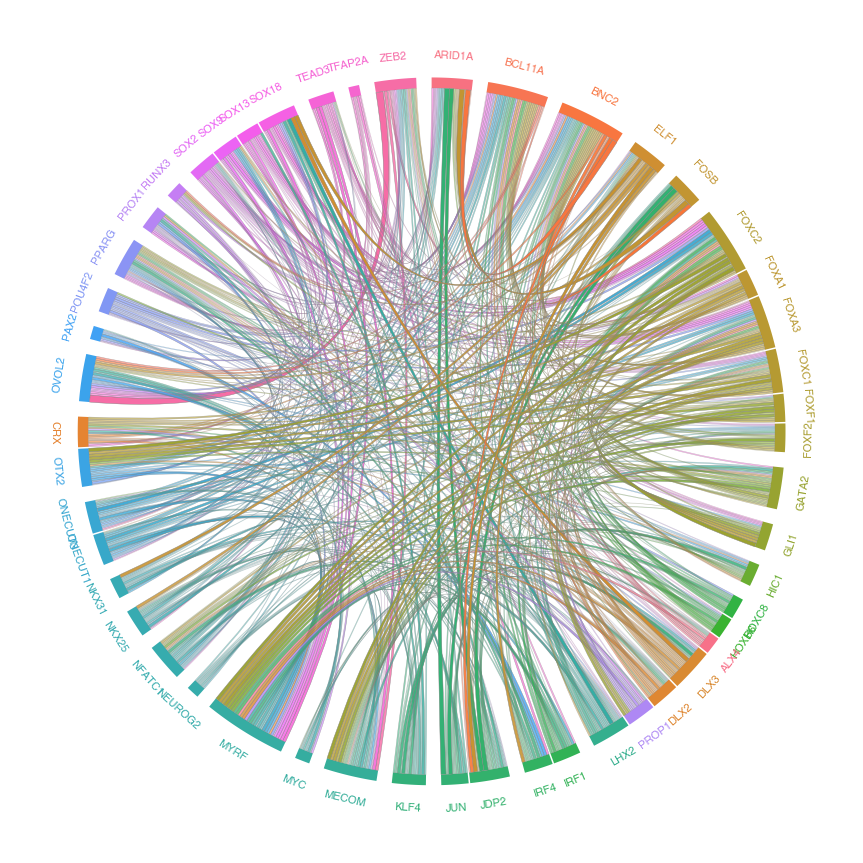

In [ ]:
from pycirclize import Circos

def alpha_by_score(from_label, to_label):
    score = np.clip(mtx.loc[from_label, to_label], 0, 1)
    return dict(alpha=float(0.1 + 0.9 * score))


circos = Circos.chord_diagram(
    mtx,
    space=spaces,
    cmap = color_mapping,
    label_kws=dict(size=8, r=105, weight="bold"),
    link_kws=dict(ec="grey", lw=0.3, alpha=0.7),
    link_cmap = link_info,
    link_kws_handler=alpha_by_score,
)

for sector in circos.sectors:
    for track in sector.tracks:
        track.axis(ec="none")

fig = circos.plotfig(figsize=(8, 8))

import matplotlib.collections as mcollections
for ax in fig.axes:
    for patch in ax.patches:
        if patch.get_edgecolor()[3] > 0:  # if edge is not already transparent
            patch.set_edgecolor("none")
    for collection in ax.collections:
        if isinstance(collection, mcollections.PatchCollection):
            collection.set_rasterized(True)
    for text in ax.texts:
        label = text.get_text()
        if label in color_mapping:
            text.set_color(color_mapping[label])

plt.tight_layout()
plt.savefig("plots/1g_priming_circos_260720_updated.pdf", dpi = 300)
plt.show()